<a href="https://colab.research.google.com/github/sanjaysaravanan8887/Rainfall_Prediction/blob/main/Rainfall_prediction_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing all Dependencies**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import pickle

**Data collection and Processing**

In [ ]:
#loading the dataset into pandas dataframe
data= pd.read_csv("/content/Rainfall.csv")

In [ ]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
data.shape

(366, 12)

In [ ]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
data.tail()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [ ]:
data["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
print("DATA INFO")
data.info()

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [ ]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [ ]:
#Remove extra spaces before
data.columns = data.columns.str.strip()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [ ]:
data =data.drop(columns=["day"])

In [ ]:
#checking simply the no.of missing values(replace with median or mean(if no outlier))
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [ ]:
#handling missing values(median)
data["windspeed"].unique()

array([26.3, 15.3, 14.2, 16.9, 13.7, 14.5, 21.5, 14.3, 39.3, 37.7, 23.3,
       23.9, 24.4, 33.2, 37.5, 40. , 23.4, 28.4, 38. , 50.6, 26.2, 35.3,
       55.5, 59.5, 28.7, 21.3, 29.6, 28.8, 25. , 21.2, 43.1, 31.9, 27.3,
        9.1, 44.7, 20.5, 16.7, 17.2, 22. , 15.8, 13.9, 10.2, 33.5, 23.5,
       19.2, 18.6, 22.2, 19.3, 28. , 20.4, 15.2,  9.2, 34.2, 27.1, 14.7,
       15.4, 13.3,  6.6, 13.8, 15.1, 39.7, 36. , 22.8, 26.7, 26.5, 13.1,
       12.5, 38.3, 42. , 19.4, 13.4, 14.6, 26.9, 14.8,  4.5,  8.3,  8. ,
       20. , 10. , 17.3, 31.8, 29.8, 11.2, 16. , 19.6, 20.9,  7.3, 11.1,
       13. ,  8.5, 24.2, 20.2, 30.5, 27. , 23.7, 11.8, 15.5, 12.1,  9.5,
       16.3, 12. , 26. , 28.6, 24.9, 28.3, 15.7, 21.9, 39.5, 30.3, 26.4,
       22.3, 25.9, 11.3,  7.9,  7.4, 16.2, 34.8, 32.5, 24. , 19. , 25.2,
       31.7, 27.4, 20.8,  9.8, 12.6,  nan, 24.3, 30. , 29.3, 23.2, 12.8,
       19.8, 12.4, 10.9,  9.6,  9. , 11.9, 26.1, 25.1, 33. , 22.5, 24.8,
       18.8, 22.4, 22.6, 12.3, 21.6, 17.5, 16.1, 14

In [ ]:
#handling missing values(mode)
data["winddirection"].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [ ]:
#handling missing values
data["winddirection"]= data["winddirection"].fillna(data["winddirection"].mode()[0])
data["windspeed"]= data["windspeed"].fillna(data["windspeed"].median())


In [ ]:
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [ ]:
#yes-1 no-0
data["rainfall"] = data["rainfall"].map({"yes": 1,"no": 0})

In [ ]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


**EXPLORATORY DATA ANALYSIS**

In [ ]:
#grid with white background (plot style for all)
sns.set(style="whitegrid")

In [ ]:
data.describe()
#if mean and median close- uniform
#else- skewed

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


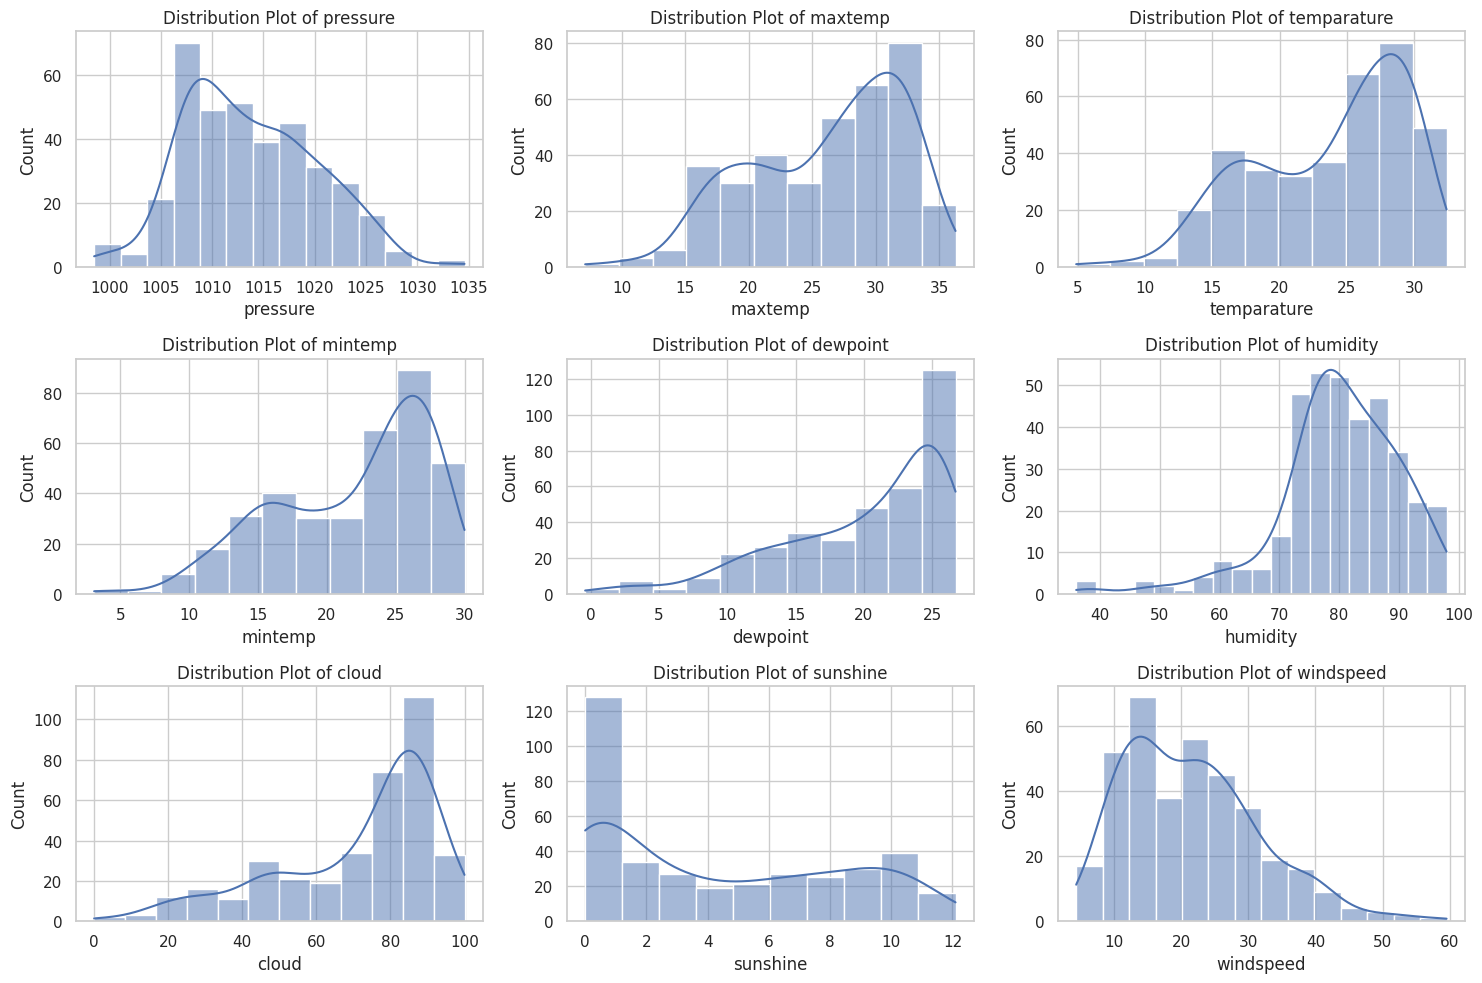

In [ ]:
#distribution plot only for numerical columns
plt.figure(figsize=(15,10))

for i, col in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3,3,i)
  sns.histplot(data[col], kde=True)
  plt.title(f"Distribution Plot of {col}")

plt.tight_layout()
plt.show()
#in regression and support vector models data should be normal(uniform) so we need to standardize in that case(standard scalar)
#in our tree based model not necessary but not wrong if we do

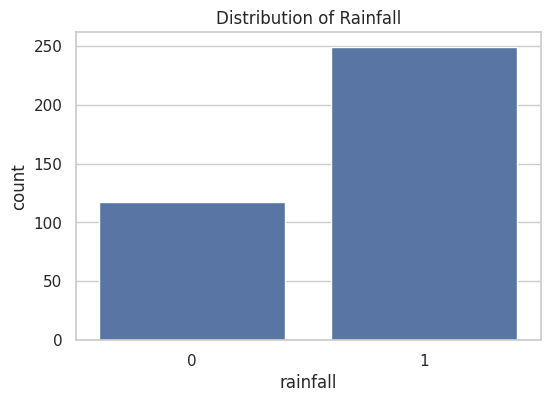

In [ ]:
#distribution of rainfall
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall", data=data)
plt.title("Distribution of Rainfall")
plt.show()
#there is a great imbalance in our dataset so we need to handle this by downsampling



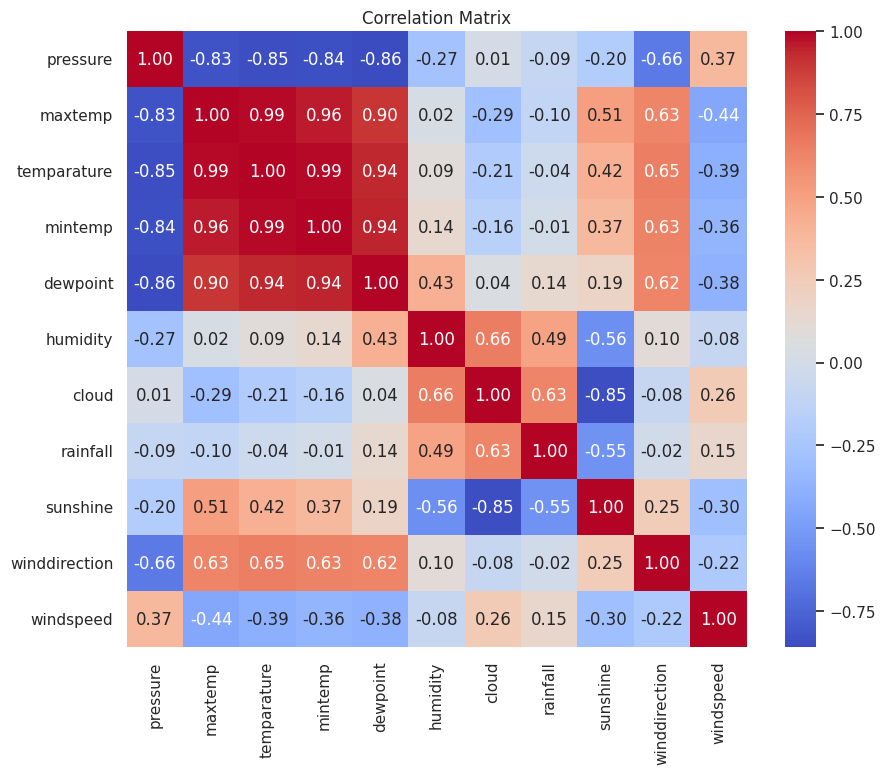

In [ ]:
#correlation matrix
corr_matrix = data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
#we are checking this to avoid multiple collinear data by dropping unwanted coloumn(1 and -1)

So till now we found to things in data multi collinearity and imbalanced target data

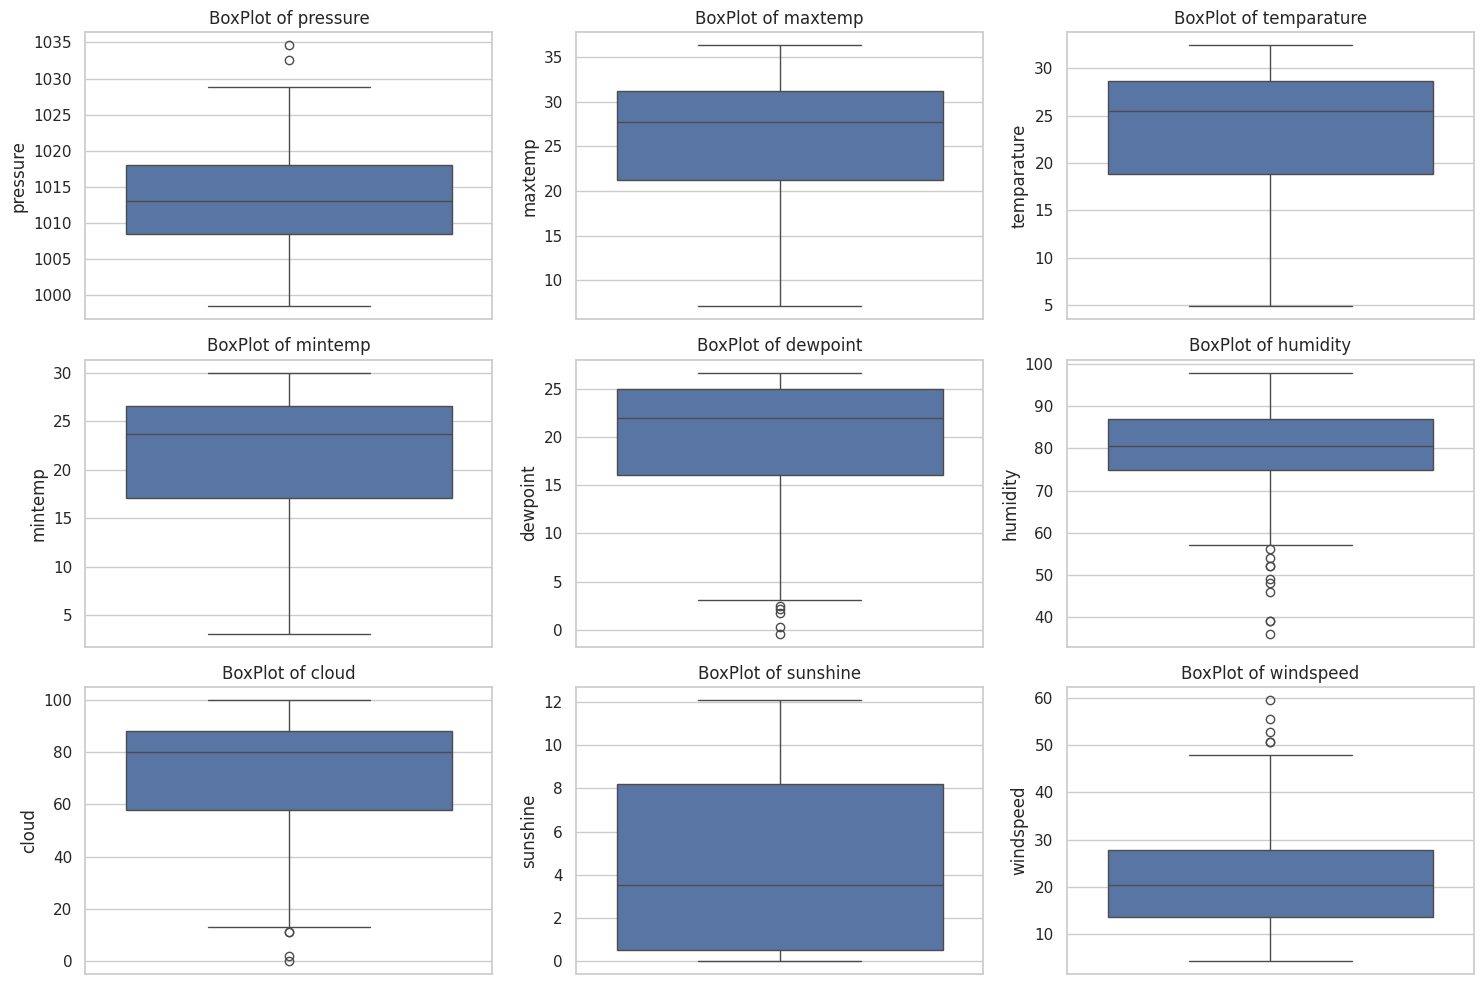

In [ ]:
#boxplot (to find presence of outliers value in data)
plt.figure(figsize=(15,10))

for i, col in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3,3,i)
  sns.boxplot(data[col])
  plt.title(f"BoxPlot of {col}")

plt.tight_layout()
plt.show()
#1.5 times interquartile(Q3-Q1) outside values are outliers
#mean is affected by outliers
#here very less so ignore

**Data Preprocessing**

In [ ]:
print(data["rainfall"].value_counts())

rainfall
1    249
0    117
Name: count, dtype: int64


In [ ]:
#spliting features and target as X and Y
X = data.drop(columns=["rainfall"])
Y = data["rainfall"]

**SPLITING DATA TO TRAIN AND TEST**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
print(Y_train.value_counts())

rainfall
1    199
0     93
Name: count, dtype: int64


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, Y_train_smote = smote.fit_resample(
    X_train,
    Y_train
)

In [ ]:
print(Y_train_smote.value_counts())

rainfall
1    199
0    199
Name: count, dtype: int64


**Model Training**

In [ ]:
#model
rf_model = RandomForestClassifier(random_state=42)
#parameters
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [ ]:
#Try every possible combination of these hyperparameters and find the best one.
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    n_jobs=-1,
    verbose=2
)
#start search
grid_search_rf.fit(X_train_smote, Y_train_smote)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
#for best model
best_rf_model = grid_search_rf.best_estimator_
print("best model:", grid_search_rf.best_estimator_)
#for best parameters
print("best parameter for Random forest:", grid_search_rf.best_params_)

best model: RandomForestClassifier(n_estimators=200, random_state=42)
best parameter for Random forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


**Cross validation on training data**

In [ ]:
cv_score=cross_val_score(best_rf_model,X_train_smote,Y_train_smote,cv=5)
print(cv_score)
print(np.mean(cv_score))

[0.8125     0.875      0.7625     0.91139241 0.93670886]
0.859620253164557


**Predicting Using test data**

In [ ]:
Y_pred = best_rf_model.predict(X_test)
print(accuracy_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))
print(classification_report(Y_test,Y_pred))

0.7972972972972973
[[17  7]
 [ 8 42]]
              precision    recall  f1-score   support

           0       0.68      0.71      0.69        24
           1       0.86      0.84      0.85        50

    accuracy                           0.80        74
   macro avg       0.77      0.77      0.77        74
weighted avg       0.80      0.80      0.80        74



**Predication using unknown data**

In [ ]:
"""input_data = (
    1015.9,  # pressure
    35.0,    # maxtemp
    30.0,    # temparature
    25.0,    # mintemp
    22.0,    # dewpoint
    80.0,    # humidity
    75.0,    # cloud
    6.0,     # sunshine
    40.0,    # winddirection
    13.7     # windspeed
)

input_df = pd.DataFrame(
    [input_data],
    columns=X.columns
)

# Same preprocessing used during training
input_scaled = scaler.transform(input_df)

input_pca = pca.transform(input_scaled)

prediction = best_rf_model.predict(input_pca)

if prediction[0] == 0:
    print("No Rainfall")
else:
    print("Rainfall")"""

'input_data = (\n    1015.9,  # pressure\n    35.0,    # maxtemp\n    30.0,    # temparature\n    25.0,    # mintemp\n    22.0,    # dewpoint\n    80.0,    # humidity\n    75.0,    # cloud\n    6.0,     # sunshine\n    40.0,    # winddirection\n    13.7     # windspeed\n)\n\ninput_df = pd.DataFrame(\n    [input_data],\n    columns=X.columns\n)\n\n# Same preprocessing used during training\ninput_scaled = scaler.transform(input_df)\n\ninput_pca = pca.transform(input_scaled)\n\nprediction = best_rf_model.predict(input_pca)\n\nif prediction[0] == 0:\n    print("No Rainfall")\nelse:\n    print("Rainfall")'

**SAVING AS PICKLE FILE**

In [ ]:
"""model_data = {
    "model": best_rf_model,
    "scaler": scaler,
    "pca": pca,
    "features": list(X.columns)
}
with open("model1.pkl", "wb") as file:
  pickle.dump(model_data, file)"""

'model_data = {\n    "model": best_rf_model,\n    "scaler": scaler,\n    "pca": pca,\n    "features": list(X.columns)\n}\nwith open("model1.pkl", "wb") as file:\n  pickle.dump(model_data, file)'

**Using in other environment**

In [ ]:
"""import pickle
import pandas as pd

with open("model1.pkl", "rb") as file:
    model_data = pickle.load(file)

model = model_data["model"]
scaler = model_data["scaler"]
pca = model_data["pca"]
features = model_data["features"]

input_data = (
    1015.9,  # pressure
    35.0,    # maxtemp
    30.0,    # temparature
    25.0,    # mintemp
    22.0,    # dewpoint
    80.0,    # humidity
    80.0,    # cloud
    6.0,     # sunshine
    40.0,    # winddirection
    13.7     # windspeed
)

input_df = pd.DataFrame([input_data], columns=features)

input_scaled = scaler.transform(input_df)
input_pca = pca.transform(input_scaled)

prediction = model.predict(input_pca)

if prediction[0] == 0:
    print("No Rainfall")
else:
    print("Rainfall")"""

'import pickle\nimport pandas as pd\n\nwith open("model1.pkl", "rb") as file:\n    model_data = pickle.load(file)\n\nmodel = model_data["model"]\nscaler = model_data["scaler"]\npca = model_data["pca"]\nfeatures = model_data["features"]\n\ninput_data = (\n    1015.9,  # pressure\n    35.0,    # maxtemp\n    30.0,    # temparature\n    25.0,    # mintemp\n    22.0,    # dewpoint\n    80.0,    # humidity\n    80.0,    # cloud\n    6.0,     # sunshine\n    40.0,    # winddirection\n    13.7     # windspeed\n)\n\ninput_df = pd.DataFrame([input_data], columns=features)\n\ninput_scaled = scaler.transform(input_df)\ninput_pca = pca.transform(input_scaled)\n\nprediction = model.predict(input_pca)\n\nif prediction[0] == 0:\n    print("No Rainfall")\nelse:\n    print("Rainfall")'